In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/neon_clean.csv")

df.head()

,timestamp,site,sensorDepth,specificConductance,dissolvedOxygen,pH,chlorophyll,turbidity,fDOM,specificCondFinalQF,dissolvedOxygenFinalQF,pHFinalQF,chlorophyllFinalQF,turbidityFinalQF,fDOMFinalQF
0,2024-01-01 00:05:21+00:00,BARC,0.4,26.95,9.84,5.43,2.27,1.65,12.15,0,0,0,0.0,0,0.0
1,2024-01-01 00:10:37+00:00,BARC,1.1,26.94,9.83,5.43,2.25,1.53,12.17,0,0,0,0.0,0,0.0
2,2024-01-01 00:15:52+00:00,BARC,1.7,27.02,9.85,5.43,1.97,1.51,12.40,0,0,0,0.0,0,0.0
3,2024-01-01 00:21:07+00:00,BARC,2.3,27.04,9.58,5.40,2.50,1.52,12.67,0,0,0,0.0,0,0.0
4,2024-01-01 00:26:22+00:00,BARC,2.9,27.01,9.67,5.41,2.74,1.56,12.91,0,0,0,0.0,0,0.0


In [3]:
df.shape

(2131254, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2131254 entries, 0 to 2131253
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   timestamp               str    
 1   site                    str    
 2   sensorDepth             float64
 3   specificConductance     float64
 4   dissolvedOxygen         float64
 5   pH                      float64
 6   chlorophyll             float64
 7   turbidity               float64
 8   fDOM                    float64
 9   specificCondFinalQF     int64  
 10  dissolvedOxygenFinalQF  int64  
 11  pHFinalQF               int64  
 12  chlorophyllFinalQF      float64
 13  turbidityFinalQF        int64  
 14  fDOMFinalQF             float64
dtypes: float64(9), int64(4), str(2)
memory usage: 243.9 MB


Matplotlib is building the font cache; this may take a moment.


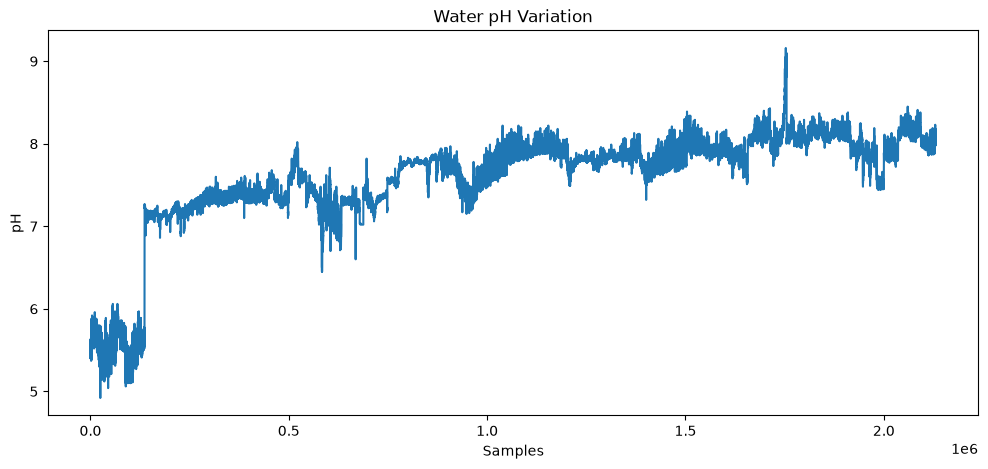

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["pH"])

plt.title("Water pH Variation")
plt.xlabel("Samples")
plt.ylabel("pH")

plt.show()

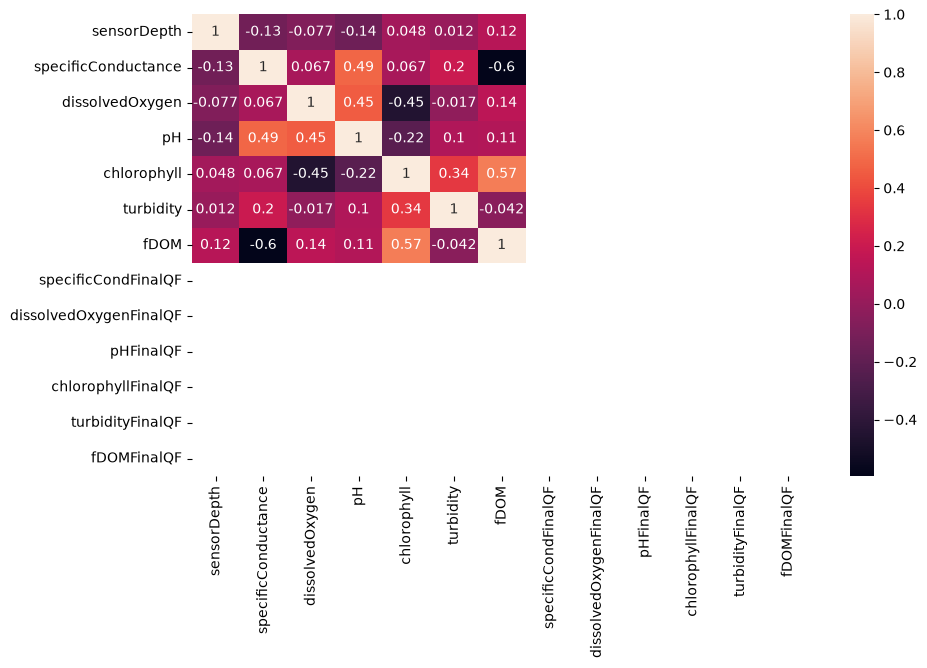

In [6]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

In [7]:
features = [
    "sensorDepth",
    "specificConductance",
    "dissolvedOxygen",
    "pH",
    "chlorophyll",
    "turbidity",
    "fDOM"
]

water_data = df[features]

water_data.head()

,sensorDepth,specificConductance,dissolvedOxygen,pH,chlorophyll,turbidity,fDOM
0,0.4,26.95,9.84,5.43,2.27,1.65,12.15
1,1.1,26.94,9.83,5.43,2.25,1.53,12.17
2,1.7,27.02,9.85,5.43,1.97,1.51,12.40
3,2.3,27.04,9.58,5.40,2.50,1.52,12.67
4,2.9,27.01,9.67,5.41,2.74,1.56,12.91


In [8]:
water_data.describe()

,sensorDepth,specificConductance,dissolvedOxygen,pH,chlorophyll,turbidity,fDOM
count,136256.000000,2.131254e+06,2.131254e+06,2.131254e+06,136256.000000,2.131254e+06,2.131254e+06
mean,0.308632,2.163030e+02,9.586355e+00,7.555122e+00,2.559656,4.196737e+00,2.978451e+01
std,0.553033,1.916708e+02,1.545698e+00,5.988129e-01,1.471163,1.194510e+01,1.931804e+01
min,-9.900000,2.104000e+01,0.000000e+00,4.920000e+00,0.010000,-0.000000e+00,-0.000000e+00
25%,0.200000,1.021700e+02,8.520000e+00,7.330000e+00,1.410000,1.920000e+00,1.407000e+01
50%,0.200000,1.192600e+02,9.700000e+00,7.750000e+00,2.240000,2.480000e+00,2.820000e+01
75%,0.300000,2.115800e+02,1.096000e+01,7.900000e+00,3.450000,3.570000e+00,4.228000e+01
max,28.700000,6.693600e+02,1.352000e+01,9.160000e+00,16.720000,2.680120e+03,1.541500e+02


Now before AI training, we need normalization

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

water_scaled = scaler.fit_transform(water_data)

water_scaled[:5]

array([[ 1.65213911e-01, -9.87907790e-01,  1.64097254e-01,
        -3.54889253e+00, -1.96890001e-01, -2.13203554e-01,
        -9.12852279e-01],
       [ 1.43096520e+00, -9.87959963e-01,  1.57627685e-01,
        -3.54889253e+00, -2.10484734e-01, -2.23249516e-01,
        -9.11816977e-01],
       [ 2.51589488e+00, -9.87542580e-01,  1.70566823e-01,
        -3.54889253e+00, -4.00810989e-01, -2.24923843e-01,
        -8.99911004e-01],
       [ 3.60082456e+00, -9.87438235e-01, -4.11153881e-03,
        -3.59899166e+00, -4.05505779e-02, -2.24086679e-01,
        -8.85934427e-01],
       [ 4.68575423e+00, -9.87594753e-01,  5.41145816e-02,
        -3.58229195e+00,  1.22586212e-01, -2.20738025e-01,
        -8.73510803e-01]])

Train anomaly detection model

In [10]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

model.fit(water_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [11]:
anomaly_labels = model.predict(water_scaled)

anomaly_labels[:20]

array([ 1,  1, -1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1])

Then count how many anomalies were detected:

In [12]:
import numpy as np

unique, counts = np.unique(anomaly_labels, return_counts=True)

dict(zip(unique, counts))

{np.int64(-1): np.int64(21313), np.int64(1): np.int64(2109941)}

In [15]:
df_results = df.copy()

df_results["anomaly_status"] = anomaly_labels

df_results.head()

df_results.columns

Index(['timestamp', 'site', 'sensorDepth', 'specificConductance',
       'dissolvedOxygen', 'pH', 'chlorophyll', 'turbidity', 'fDOM',
       'specificCondFinalQF', 'dissolvedOxygenFinalQF', 'pHFinalQF',
       'chlorophyllFinalQF', 'turbidityFinalQF', 'fDOMFinalQF',
       'anomaly_status'],
      dtype='str')

In [16]:
anomaly_view = df_results[
    [
        "timestamp",
        "site",
        "pH",
        "turbidity",
        "dissolvedOxygen",
        "fDOM",
        "anomaly_status"
    ]
]

anomaly_view.head()

,timestamp,site,pH,turbidity,dissolvedOxygen,fDOM,anomaly_status
0,2024-01-01 00:05:21+00:00,BARC,5.43,1.65,9.84,12.15,1
1,2024-01-01 00:10:37+00:00,BARC,5.43,1.53,9.83,12.17,1
2,2024-01-01 00:15:52+00:00,BARC,5.43,1.51,9.85,12.40,-1
3,2024-01-01 00:21:07+00:00,BARC,5.40,1.52,9.58,12.67,1
4,2024-01-01 00:26:22+00:00,BARC,5.41,1.56,9.67,12.91,-1


In [17]:
anomalies = anomaly_view[
    anomaly_view["anomaly_status"] == -1
]

anomalies.head()

,timestamp,site,pH,turbidity,dissolvedOxygen,fDOM,anomaly_status
2,2024-01-01 00:15:52+00:00,BARC,5.43,1.51,9.85,12.40,-1
4,2024-01-01 00:26:22+00:00,BARC,5.41,1.56,9.67,12.91,-1
5,2024-01-01 00:31:37+00:00,BARC,5.42,1.58,9.74,12.78,-1
6,2024-01-01 00:36:54+00:00,BARC,5.43,1.58,9.86,12.88,-1
51,2024-01-01 04:26:29+00:00,BARC,5.43,1.59,9.76,13.00,-1


unusal locations

In [19]:
df_results[df_results["anomaly_status"] == -1]["site"].value_counts()

site
BARC    13045
BLUE     7206
BIGC      931
BLDE      131
Name: count, dtype: int64

In [21]:
unusual = df_results[df_results["anomaly_status"] == -1]

unusual[
    [
        "timestamp",
        "site",
        "pH",
        "turbidity",
        "dissolvedOxygen",
        "fDOM",
        "anomaly_status"
    ]
].head(5)

,timestamp,site,pH,turbidity,dissolvedOxygen,fDOM,anomaly_status
2,2024-01-01 00:15:52+00:00,BARC,5.43,1.51,9.85,12.40,-1
4,2024-01-01 00:26:22+00:00,BARC,5.41,1.56,9.67,12.91,-1
5,2024-01-01 00:31:37+00:00,BARC,5.42,1.58,9.74,12.78,-1
6,2024-01-01 00:36:54+00:00,BARC,5.43,1.58,9.86,12.88,-1
51,2024-01-01 04:26:29+00:00,BARC,5.43,1.59,9.76,13.00,-1


In [24]:
df_results["timestamp"] = pd.to_datetime(df_results["timestamp"])

df_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 2131254 entries, 0 to 2131253
Data columns (total 16 columns):
 #   Column                  Dtype              
---  ------                  -----              
 0   timestamp               datetime64[us, UTC]
 1   site                    str                
 2   sensorDepth             float64            
 3   specificConductance     float64            
 4   dissolvedOxygen         float64            
 5   pH                      float64            
 6   chlorophyll             float64            
 7   turbidity               float64            
 8   fDOM                    float64            
 9   specificCondFinalQF     int64              
 10  dissolvedOxygenFinalQF  int64              
 11  pHFinalQF               int64              
 12  chlorophyllFinalQF      float64            
 13  turbidityFinalQF        int64              
 14  fDOMFinalQF             float64            
 15  anomaly_status          int64              
dtypes: datetime

In [25]:
import matplotlib.pyplot as plt

normal = df_results[df_results["anomaly_status"] == 1].sample(5000)
anomalies = df_results[df_results["anomaly_status"] == -1]

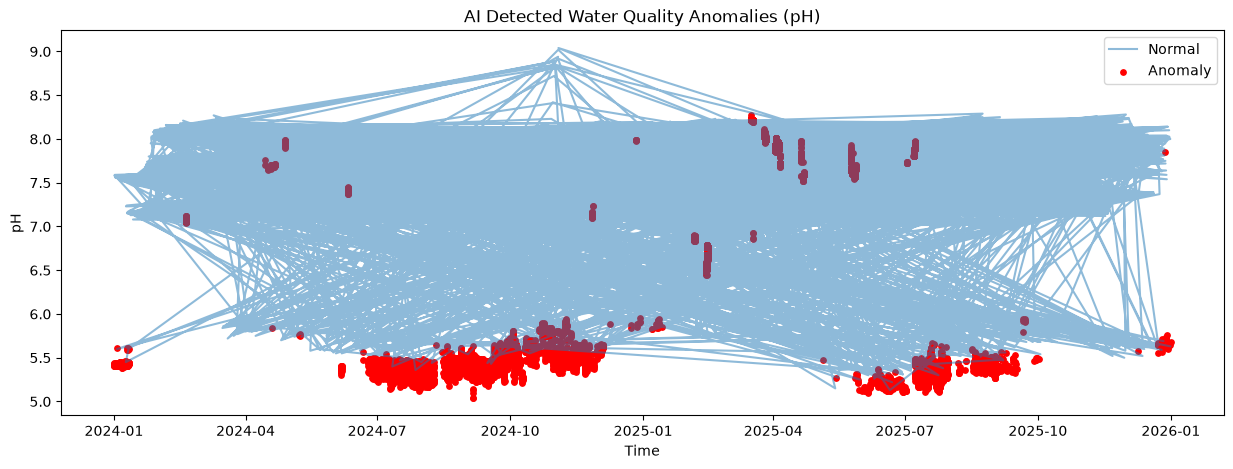

In [26]:
plt.figure(figsize=(15,5))

plt.plot(
    normal["timestamp"],
    normal["pH"],
    label="Normal",
    alpha=0.5
)

plt.scatter(
    anomalies["timestamp"],
    anomalies["pH"],
    color="red",
    s=15,
    label="Anomaly"
)

plt.title("AI Detected Water Quality Anomalies (pH)")
plt.xlabel("Time")
plt.ylabel("pH")
plt.legend()

plt.show()

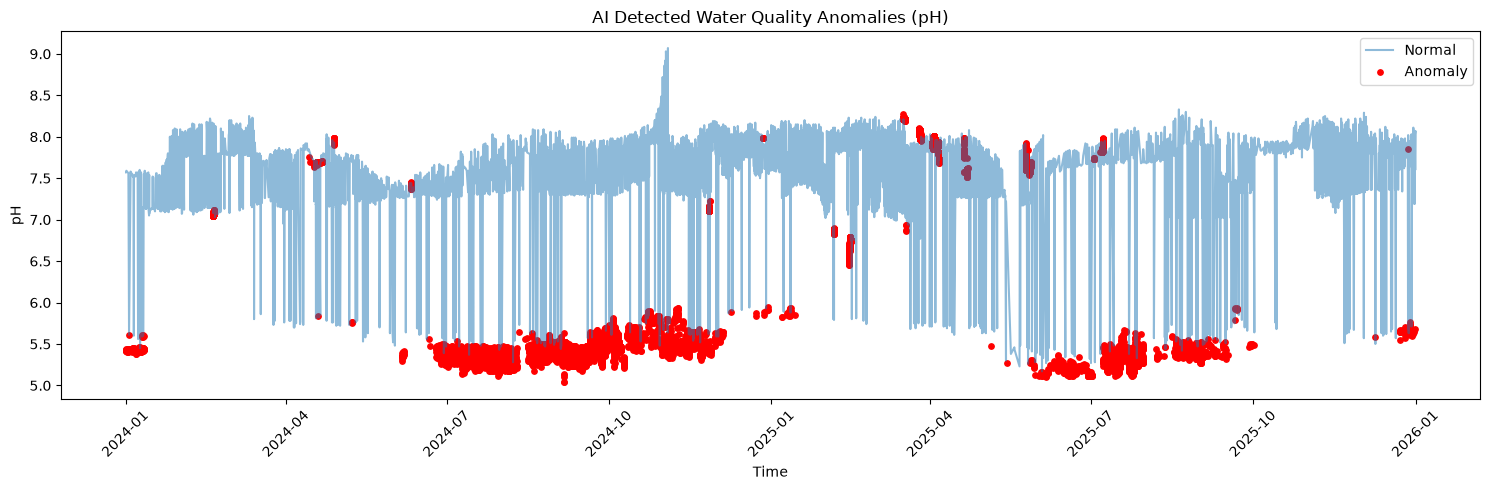

In [27]:
plt.figure(figsize=(15,5))

normal = df_results[df_results["anomaly_status"] == 1].sample(5000)
normal = normal.sort_values("timestamp")

anomalies = df_results[df_results["anomaly_status"] == -1]
anomalies = anomalies.sort_values("timestamp")


plt.plot(
    normal["timestamp"],
    normal["pH"],
    label="Normal",
    alpha=0.5
)

plt.scatter(
    anomalies["timestamp"],
    anomalies["pH"],
    color="red",
    s=15,
    label="Anomaly"
)


plt.title("AI Detected Water Quality Anomalies (pH)")
plt.xlabel("Time")
plt.ylabel("pH")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [28]:
import numpy as np

risk_data = df_results.copy()

# pH risk
ph_risk = np.abs(risk_data["pH"] - 7) / 3

# turbidity risk
turbidity_risk = risk_data["turbidity"] / risk_data["turbidity"].max()

# dissolved oxygen risk
do_risk = 1 - (risk_data["dissolvedOxygen"] / risk_data["dissolvedOxygen"].max())

# fDOM organic contamination risk
fdom_risk = risk_data["fDOM"] / risk_data["fDOM"].max()


risk_data["water_risk_score"] = (
    ph_risk*25 +
    turbidity_risk*30 +
    do_risk*20 +
    fdom_risk*25
)

risk_data["water_risk_score"] = (
    risk_data["water_risk_score"]
    .clip(0,100)
)

risk_data.head()

,timestamp,site,sensorDepth,specificConductance,dissolvedOxygen,pH,chlorophyll,turbidity,fDOM,specificCondFinalQF,dissolvedOxygenFinalQF,pHFinalQF,chlorophyllFinalQF,turbidityFinalQF,fDOMFinalQF,anomaly_status,water_risk_score
0,2024-01-01 00:05:21+00:00,BARC,0.4,26.95,9.84,5.43,2.27,1.65,12.15,0,0,0,0.0,0,0.0,1,20.516073
1,2024-01-01 00:10:37+00:00,BARC,1.1,26.94,9.83,5.43,2.25,1.53,12.17,0,0,0,0.0,0,0.0,1,20.532766
2,2024-01-01 00:15:52+00:00,BARC,1.7,27.02,9.85,5.43,1.97,1.51,12.40,0,0,0,0.0,0,0.0,-1,20.540258
3,2024-01-01 00:21:07+00:00,BARC,2.3,27.04,9.58,5.40,2.50,1.52,12.67,0,0,0,0.0,0,0.0,1,21.233567
4,2024-01-01 00:26:22+00:00,BARC,2.9,27.01,9.67,5.41,2.74,1.56,12.91,0,0,0,0.0,0,0.0,-1,21.056468


In [29]:
def risk_level(score):
    if score < 30:
        return "SAFE"
    elif score < 60:
        return "WARNING"
    else:
        return "CRITICAL"


risk_data["risk_level"] = risk_data["water_risk_score"].apply(risk_level)

risk_data.head()

,timestamp,site,sensorDepth,specificConductance,dissolvedOxygen,pH,chlorophyll,turbidity,fDOM,specificCondFinalQF,dissolvedOxygenFinalQF,pHFinalQF,chlorophyllFinalQF,turbidityFinalQF,fDOMFinalQF,anomaly_status,water_risk_score,risk_level
0,2024-01-01 00:05:21+00:00,BARC,0.4,26.95,9.84,5.43,2.27,1.65,12.15,0,0,0,0.0,0,0.0,1,20.516073,SAFE
1,2024-01-01 00:10:37+00:00,BARC,1.1,26.94,9.83,5.43,2.25,1.53,12.17,0,0,0,0.0,0,0.0,1,20.532766,SAFE
2,2024-01-01 00:15:52+00:00,BARC,1.7,27.02,9.85,5.43,1.97,1.51,12.40,0,0,0,0.0,0,0.0,-1,20.540258,SAFE
3,2024-01-01 00:21:07+00:00,BARC,2.3,27.04,9.58,5.40,2.50,1.52,12.67,0,0,0,0.0,0,0.0,1,21.233567,SAFE
4,2024-01-01 00:26:22+00:00,BARC,2.9,27.01,9.67,5.41,2.74,1.56,12.91,0,0,0,0.0,0,0.0,-1,21.056468,SAFE


In [30]:
risk_data[
    [
    "timestamp",
    "site",
    "pH",
    "turbidity",
    "dissolvedOxygen",
    "fDOM",
    "anomaly_status",
    "water_risk_score",
    "risk_level"
    ]
].head()

,timestamp,site,pH,turbidity,dissolvedOxygen,fDOM,anomaly_status,water_risk_score,risk_level
0,2024-01-01 00:05:21+00:00,BARC,5.43,1.65,9.84,12.15,1,20.516073,SAFE
1,2024-01-01 00:10:37+00:00,BARC,5.43,1.53,9.83,12.17,1,20.532766,SAFE
2,2024-01-01 00:15:52+00:00,BARC,5.43,1.51,9.85,12.40,-1,20.540258,SAFE
3,2024-01-01 00:21:07+00:00,BARC,5.40,1.52,9.58,12.67,1,21.233567,SAFE
4,2024-01-01 00:26:22+00:00,BARC,5.41,1.56,9.67,12.91,-1,21.056468,SAFE


In [31]:
risk_data["final_risk_score"] = (
    risk_data["water_risk_score"]
    +
    (risk_data["anomaly_status"] == -1) * 40
)

risk_data["final_risk_score"] = (
    risk_data["final_risk_score"].clip(0,100)
)


def final_risk(score):
    if score < 30:
        return "SAFE"
    elif score < 60:
        return "WARNING"
    else:
        return "CRITICAL"


risk_data["final_status"] = (
    risk_data["final_risk_score"]
    .apply(final_risk)
)


risk_data[
[
"timestamp",
"site",
"pH",
"turbidity",
"dissolvedOxygen",
"anomaly_status",
"final_risk_score",
"final_status"
]
].head(10)

,timestamp,site,pH,turbidity,dissolvedOxygen,anomaly_status,final_risk_score,final_status
0,2024-01-01 00:05:21+00:00,BARC,5.43,1.65,9.84,1,20.516073,SAFE
1,2024-01-01 00:10:37+00:00,BARC,5.43,1.53,9.83,1,20.532766,SAFE
2,2024-01-01 00:15:52+00:00,BARC,5.43,1.51,9.85,-1,60.540258,CRITICAL
3,2024-01-01 00:21:07+00:00,BARC,5.40,1.52,9.58,1,21.233567,SAFE
4,2024-01-01 00:26:22+00:00,BARC,5.41,1.56,9.67,-1,61.056468,CRITICAL
5,2024-01-01 00:31:37+00:00,BARC,5.42,1.58,9.74,-1,60.848725,CRITICAL
6,2024-01-01 00:36:54+00:00,BARC,5.43,1.58,9.86,-1,60.604095,CRITICAL
7,2024-01-01 00:42:01+00:00,BARC,5.60,1.58,9.86,1,19.052819,SAFE
8,2024-01-01 00:47:01+00:00,BARC,5.60,1.59,9.83,1,19.128124,SAFE
9,2024-01-01 00:52:01+00:00,BARC,5.60,1.40,9.82,1,19.150521,SAFE


In [32]:
risk_data.to_csv(
    "results/final_water_quality_prediction.csv",
    index=False
)

In [33]:
import os

os.path.exists(
"results/final_water_quality_prediction.csv"
)

True